In [23]:
class DisjointSet: #Union-Find https://en.wikipedia.org/wiki/Disjoint-set_data_structure
  def __init__(self, items = None):
    self.djs_forest = dict()
    if not items is None:
      for x in items: self.djs_forest[x] = DisjointSet.DisjointSetItem(x)
  def makeSet(self, x):
    if not x in self.djs_forest:
      self.djs_forest[x] = DisjointSet.DisjointSetItem(x)
  def delSet(self, x):
    #if self.djs_forest[x].parent != self.djs_forest[x] and any(self.djs_forest[x] == y.parent for y in self.djs_forest): raise ValueError
    del self.djs_forest[x]
  def unmerge(self, tree):
    for x in tree: self.djs_forest[x].parent = self.djs_forest[x]
  def find(self, item):
    return DisjointSet._find_internal(self.djs_forest[item]).value
  def _find_internal(item): #path compression
    #if item.parent != item: item.parent = DisjointSet._find_internal(item.parent)
    #return item.parent
    root = item #non-recursive path compression algorithm
    while root.parent != root:
      root = root.parent
    while item.parent != root:
      parent = item.parent
      item.parent = root
      item = parent
    return root
  def union(self, set1, set2, ordered = False):
    return DisjointSet._union_internal(self.djs_forest[set1], self.djs_forest[set2], ordered)
  def _union_internal(set1, set2, ordered):
    root1 = DisjointSet._find_internal(set1)
    root2 = DisjointSet._find_internal(set2)
    if root1 == root2: return
    #if root1.size < root2.size:
    if not ordered and root1.rank < root2.rank:
      root1, root2 = root2, root1
    root2.parent = root1
    if root1.rank == root2.rank: root1.rank += 1
    #root1.size += root2.size
  def __repr__(self): return str(self)
  def __str__(self): return str({str((x, str(self.djs_forest[x]))) for x in self.djs_forest})
  class DisjointSetItem:
    def __init__(self, x):
      self.value = x
      self.parent = self
      self.rank = 0
      #self.size = 1
    def __repr__(self): return str(self)
    def __str__(self): return str((self.value, self.parent.value, self.rank))
class Tree:
  def __init__(self, root=1, init=None, pred_init=None, dict_pred_init=None, check_validity=False, use_depth=False):
    self.virtual_root = root; self.succ, self.pred = {root: []}, {root: None}
    if use_depth: self.level = {root: 0}
    self.check_validity = check_validity; self.use_depth = use_depth
    self.root_succ = []
    if not init is None:
      for x in range(1, len(init)+1):
        if x != root: self.add_node(x)
      for i, x in enumerate(init):
        for y in x: self.add_edge(i + 1, y)
    elif not pred_init is None:
      for i, x in enumerate(pred_init):
        if i + 1 == self.virtual_root: continue
        self.add_node(i + 1)
      for i, x in enumerate(pred_init):
        if i + 1 == self.virtual_root: continue
        self.add_edge(x, i + 1)
    elif not dict_pred_init is None:
      for x in dict_pred_init:
        if x == self.virtual_root: continue
        self.add_node(x)
      for x in dict_pred_init:
        if x == self.virtual_root: continue
        self.add_edge(dict_pred_init[x], x)
  def graphviz_dot(self, lbl, ordered=None):
    if len(self.succ) == 1: return str(self.virtual_root)
    s = ";".join(lbl + str(x) + "->" + lbl + str(y) for x in self.succ for y in (self.succ[x] if ordered is None else sorted(self.succ[x], key=lambda z: ordered[z])))
    return s #return "digraph { rankdir=TB; " + s + "}"
  def add_node(self, n):
    self.succ[n], self.pred[n] = [], self.virtual_root
    if self.use_depth: self.level[n] = self.level[self.virtual_root] + 1
    self.succ[self.virtual_root].append(n)
    if self.check_validity: self.checkTreeValid()
  def remove_node(self, n):
    #print(n, self.succ[n], self.pred[n], self.root_succ)
    if len(self.succ[n]) == 0 and self.pred[n] == self.virtual_root and not n in self.root_succ:
      del self.succ[n]; del self.pred[n]; self.succ[self.virtual_root].remove(n)
      if self.use_depth: del self.level[n]
    else: raise ValueError
    if self.check_validity: self.checkTreeValid()
  def add_edge(self, x, y, delay_redepth=False):
    if self.pred[y] != self.virtual_root: raise ValueError
    if x == self.virtual_root:
      self.root_succ.append(y)
      return
    self.succ[self.virtual_root].remove(y)
    self.succ[x].append(y); self.pred[y] = x
    if self.use_depth and not delay_redepth: self.level[y] = self.level[x] + 1; self.redepthSubTree(y)
    if self.check_validity: self.checkTreeValid()
  def add_edge_first(self, x, y, delay_redepth=False):
    if self.pred[y] != self.virtual_root: raise ValueError
    if x == self.virtual_root:
      self.root_succ.insert(0, y)
      self.succ[x].remove(y)
      self.succ[x].insert(0, y)
      return
    self.succ[self.virtual_root].remove(y)
    self.succ[x].insert(0, y); self.pred[y] = x
    if self.use_depth and not delay_redepth: self.level[y] = self.level[x] + 1; self.redepthSubTree(y)
    if self.check_validity: self.checkTreeValid()
  def add_edge_after(self, x, y, v, delay_redepth=False):
    if self.pred[y] != self.virtual_root: raise ValueError
    if x == self.virtual_root:
      self.root_succ.insert(self.root_succ.index(v)+1, y)
      self.succ[x].remove(y)
      self.succ[x].insert(self.succ[x].index(v)+1, y)
      return
    self.succ[self.virtual_root].remove(y)
    self.succ[x].insert(self.succ[x].index(v)+1, y); self.pred[y] = x
    if self.use_depth and not delay_redepth: self.level[y] = self.level[x] + 1; self.redepthSubTree(y)
    if self.check_validity: self.checkTreeValid()
  def remove_edge(self, x, y, delay_redepth=False):
    #print((x, y))
    if not y in self.succ[x]: raise ValueError
    if x == self.virtual_root:
      if y in self.root_succ: self.root_succ.remove(y)
    else: self.succ[self.virtual_root].append(y); self.succ[x].remove(y); self.pred[y] = self.virtual_root
    if self.use_depth and not delay_redepth: self.level[y] = self.level[self.virtual_root] + 1; self.redepthSubTree(y)
    if self.check_validity: self.checkTreeValid()
  def redepthSubTrees(self, xs): #xs must be sorted in by least ancestor
    i, visited = 0, set()
    while len(xs) != i:
      x = xs[i]
      if x in visited: i += 1; continue
      redepth = [x]
      self.level[x] = self.level[self.pred[x]] + 1
      while len(redepth) != 0:
        x = redepth.pop()
        visited.add(x)
        for y in self.succ[x]:
          self.level[y] = self.level[x] + 1
          redepth.append(y)
      i += 1
  def redepthSubTree(self, x):
    redepth = [x]
    while len(redepth) != 0:
      x = redepth.pop()
      for y in self.succ[x]:
        self.level[y] = self.level[x] + 1
        redepth.append(y)
  def lca(self, x, y):
    path = set()
    while not y is None: path.add(y); y = self.pred[y]
    while not x in path and x != self.virtual_root: x = self.pred[x]#; if x is None: raise ValueError
    return x
  def lcam(self, nodes):
    it = iter(nodes)
    n = next(it)
    for x in it:
      n = self.lca(n, x)
    return n
  def allAncestors(self, x, top = None):
    path = set()
    while x != top and not x is None: path.add(x); x = self.pred[x]
    return path
  def isAncestor(self, x, y):
    while not x is None:
      if x == y: return True
      x = self.pred[x]
    return False
  def subTree(self, x):
    visit, subtree = [x], set()
    while len(visit) != 0:
      x = visit.pop(); subtree.add(x)
      visit.extend(self.succ[x])
    return subtree
  def bfsSubTree(self, x):
    visit, idx = [x], 0
    while len(visit) > idx:
      visit.extend(self.succ[visit[idx]])
      idx += 1
    return visit
  def treeByLevel(self):
    visit, levels = [self.virtual_root], []
    while len(visit) != 0:
      x = visit.pop()
      if len(levels) == self.level[x]: levels.append([])
      levels[self.level[x]].append(x)
      visit.extend(self.succ[x])
    return levels
  def __eq__(self, other):
    return self.pred == other.pred
  def checkTreeValid(self):
    for x in self.root_succ:
      if not x in self.succ[self.virtual_root]: raise ValueError("Bad Virtual Root", self.root_succ, self.succ[self.virtual_root])
    visit = [self.virtual_root]
    l = 0
    while len(visit) != 0:
      x = visit.pop(); l += 1
      for y in self.succ[x]:
        if self.pred[y] != x: raise ValueError("Bad Predecessor", x, y)
        if self.use_depth and self.level[y] != self.level[x] + 1: raise ValueError("Bad Level", x, y)
      visit.extend(self.succ[x])
    if len(self.succ) != l: raise ValueError("Bad Successors", self.succ, l)
  def __repr__(self): return str(self)
  def __str__(self): return str(self.pred)
def do_dfs(sources, succ, test_order=None):
  virtual_root = 0
  allsources = sources + list(filter(lambda x: not x in sources, succ))
  stack, t, visited = [(virtual_root, None)], 1, set()
  dfs_tree, dfs_int, dfs_revint = Tree(virtual_root), {}, {}
  while len(stack) != 0:
    x, pre = stack.pop()
    if pre is None:
      visited.add(x)
      dfs_int[x] = [t, None]
      dfs_revint[t] = x
      t += 1
      pre = iter(succ[x] if x != virtual_root else allsources) if test_order is None else sorted(succ[x] if x != virtual_root else allsources, key=lambda y: test_order[y][0])
    for y in pre:
      if not y in visited:
        dfs_tree.add_node(y); dfs_tree.add_edge(x, y)
        stack.append((x, pre)); stack.append((y, None)); break
    else:
      dfs_int[x][1] = t
      dfs_revint[t] = x
      t += 1
  return dfs_tree, dfs_int, dfs_revint
def do_isBackEdge(dfs_tree, dfs_int, x, y): return dfs_tree.pred[y] != x and do_isAncestor(dfs_int, y, x)
def do_isAncestor(dfs_int, x, y): return range_subsetof(dfs_int[y], dfs_int[x])
def range_subsetof(r1, r2): return r1[0] >= r2[0] and r1[1] <= r2[1]
def do_tarjan_is_reducible(G):
  succ, pred = {}, {}
  for x, y, _ in G.edges():
      if not x in succ: succ[x], pred[x] = [], []
      if not y in succ: succ[y], pred[y] = [], []
      succ[x].append(y)
      pred[y].append(x)
  dfs_tree, dfs_int, dfs_revint = do_dfs(G.vertices(), succ)
  lp = DisjointSet(pred.keys())
  for widx in reversed(list(dfs_revint)):
    w = dfs_revint[widx]
    if w == 0 or dfs_int[w][1] == widx: continue
    p = set()
    worklist = {lp.find(v) for v in pred[w] if do_isBackEdge(dfs_tree, dfs_int, v, w)}
    if w in worklist: worklist.remove(w)
    while len(worklist) != 0:
      x = worklist.pop()
      p.add(x)
      for y in pred[x]:
        if y == x or do_isBackEdge(dfs_tree, dfs_int, y, x): continue
        yprime = lp.find(y)
        if not do_isAncestor(dfs_int, w, yprime):
          #assert any(x == IRREDUCIBLE for x in havlak_loops(pred, dfs_tree, dfs_int, dfs_revint)[1].values())
          return False
        if not yprime in p and yprime != w: worklist.add(yprime)
    for x in p: lp.union(w, x, True)
  return True
def sage_digraphs_loops(vertices, property=lambda x: True, size=None, sparse=True):
  if size is not None:
      extra_property = lambda x: x.size() == size
  else:
      extra_property = lambda x: True
  from sage.graphs.graph_generators import canaug_traverse_edge
  g = DiGraph(vertices, loops=True, sparse=sparse)
  gens = []
  for i in range(vertices-1):
      gen = list(range(i))
      gen.append(i+1); gen.append(i)
      gen += list(range(i+2, vertices))
      gens.append(gen)
  for gg in canaug_traverse_edge(g, gens, property, dig=True, loops=True, sparse=sparse):
      if extra_property(gg):
          yield gg

In [65]:
[sum(1 for _ in sage_digraphs_loops(n)) for n in range(5)] #A000595 Relations: number of nonisomorphic unlabeled binary relations on n labeled nodes.

[1, 2, 10, 104, 3044]

In [66]:
[sum(1 for _ in digraphs(n)) for n in range(6)] #A000273 Number of directed graphs (or digraphs) with n nodes.

[1, 1, 3, 16, 218, 9608]

In [2]:
totulblacyclicdigraphs = [len(list(digraphs(n, property=lambda g: g.is_directed_acyclic()))) for n in range(7)] #A003087 Number of acyclic digraphs with n unlabeled nodes.  
print(totulblacyclicdigraphs)

[1, 1, 2, 6, 31, 302, 5984]


In [10]:
[len(list(x for x in digraphs(n, property=lambda g: g.is_directed_acyclic()) if len(x.strongly_connected_components_digraph().sources())<=1)) for n in range(7)] #A350415 Number of acyclic digraphs on n unlabeled nodes with a global source (or sink).

[1, 1, 1, 3, 16, 164, 3341]

In [132]:
([len(list(x for x in digraphs(n) if len(x.strongly_connected_components_digraph().sources())<=1)) for n in range(6)], #A051421 Number of digraphs on n unlabeled nodes with a sink (or, with a source).
#[len(list(digraphs(n, property=lambda g: len(g.complement().strongly_connected_components_digraph().sources()) <= 1))) for n in range(6)] #A051421 Number of digraphs on n unlabeled nodes with a sink (or, with a source).
#[len(list(x for x in digraphs(n) if len(list(x.depth_first_search(0, ignore_direction=True))) == n)) for n in range(6)] #A003085 Number of weakly connected digraphs with n unlabeled nodes.
#[len(list(digraphs(n, property=lambda g: len(list(g.complement().depth_first_search(0, ignore_direction=True))) == n))) for n in range(6)] #A003085 Number of weakly connected digraphs with n unlabeled nodes.
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs(n) if len(x.strongly_connected_components_digraph().sources())<=1) for n in range(6)])

([1, 1, 2, 12, 185, 8990], [1, 1, 3, 51, 3614, 991930])

In [128]:
([len(list(x for x in sage_digraphs_loops(n) if len(x.strongly_connected_components_digraph().sources())<=1)) for n in range(5)],
#[len(list(x for x in sage_digraphs_loops(n) if len(list(x.depth_first_search(0, ignore_direction=True))) == n)) for n in range(5)] #A054919 Number of nonisomorphic connected unlabeled binary relations on n nodes.
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in sage_digraphs_loops(n) if len(x.strongly_connected_components_digraph().sources())<=1) for n in range(5)])

([1, 2, 7, 80, 2638], [1, 2, 12, 408, 57824])

In [209]:
([len(list(x for x in digraphs(n) if x.is_strongly_connected())) for n in range(6)],
#[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs.tournaments_nauty(n)) for n in range(6)], #A006125 a(n) = 2^(n*(n-1)/2).
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs.tournaments_nauty(n, strongly_connected=True)) for n in range(8)], #A054946 Number of strongly connected labeled tournaments on n nodes.
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs.tournaments_nauty(n, strongly_connected=True) if do_tarjan_is_reducible(x)) for n in range(8)],
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs.tournaments_nauty(n, strongly_connected=True) if not do_tarjan_is_reducible(x)) for n in range(8)],
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs(n) if x.is_strongly_connected() and len(x.edges()) == n*(n-1)//2 and all((j in x.neighbor_out_iterator(i))!=(j in x.neighbor_in_iterator(i)) for i in x.vertices() for j in x.vertices() if i != j)) for n in range(5)], #A054946 Number of strongly connected labeled tournaments on n nodes.
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs(n) if x.is_strongly_connected()) for n in range(5)])

([1, 1, 1, 5, 83, 5048],
 [0, 1, 0, 2, 24, 544, 22320, 1677488],
 [0, 1, 0, 2, 24, 240, 4320, 75600],
 [0, 0, 0, 0, 0, 304, 18000, 1601888],
 [1, 1, 0, 2, 24],
 [1, 1, 1, 18, 1606])

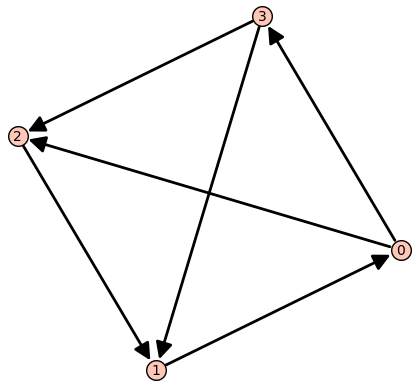

([0, 1, 0, 1, 1, 2, 6, 15, 38], [0, 0, 0, 0, 0, 4, 29, 338, 5970])

In [227]:
[x.plot().show() for x in digraphs.tournaments_nauty(4, strongly_connected=True)]
([sum(1 for x in digraphs.tournaments_nauty(n, strongly_connected=True) if do_tarjan_is_reducible(x)) for n in range(9)],
[sum(1 for x in digraphs.tournaments_nauty(n, strongly_connected=True) if not do_tarjan_is_reducible(x)) for n in range(9)])

In [179]:
([len(list(x for x in sage_digraphs_loops(n) if x.is_strongly_connected())) for n in range(5)],
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in sage_digraphs_loops(n) if x.is_strongly_connected() and len(x.edges()) >= n*(n-1)//2 and all((j in x.neighbor_out_iterator(i))!=(j in x.neighbor_in_iterator(i)) for i in x.vertices() for j in x.vertices() if i != j)) for n in range(5)],
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in sage_digraphs_loops(n) if x.is_strongly_connected()) for n in range(5)])

([1, 2, 3, 30, 1168], [1, 2, 0, 16, 384], [1, 2, 4, 144, 25696])

In [112]:
[len(list(x for x in digraphs(n) if x.is_strongly_connected() and do_tarjan_is_reducible(x))) for n in range(6)]

[0, 0, 0, 2, 59, 4653]

In [113]:
[len(list(x for x in sage_digraphs_loops(n) if x.is_strongly_connected() and do_tarjan_is_reducible(x))) for n in range(5)]

[0, 0, 0, 12, 809]

In [69]:
#[len(list(x for x in digraphs(n) if not x.is_directed_acyclic() and len(x.strongly_connected_components_digraph().sources())<=1)) for n in range(6)]
[len(list(x for x in digraphs(n) if not x.is_directed_acyclic() and len(x.strongly_connected_components_digraph().sources())<=1 and not do_tarjan_is_reducible(x))) for n in range(6)]

[0, 0, 0, 3, 104, 7363]

In [70]:
[len(list(x for x in sage_digraphs_loops(n) if not x.is_directed_acyclic() and len(x.strongly_connected_components_digraph().sources())<=1)) for n in range(5)]

[0, 1, 6, 77, 2622]

In [72]:
[len(list(x for x in sage_digraphs_loops(n) if not x.is_directed_acyclic() and len(x.strongly_connected_components_digraph().sources())<=1 and not do_tarjan_is_reducible(x))) for n in range(6)]

[0, 0, 0, 18, 1440, 222568]

In [21]:
[len(list(x for x in digraphs(n) if not x.is_directed_acyclic() and len(x.strongly_connected_components_digraph().sources())<=1 and do_tarjan_is_reducible(x))) for n in range(6)]

[0, 0, 1, 6, 65, 1463]

In [22]:
[len(list(x for x in sage_digraphs_loops(n) if not x.is_directed_acyclic() and len(x.strongly_connected_components_digraph().sources())<=1 and do_tarjan_is_reducible(x))) for n in range(5)]

[0, 1, 6, 59, 1182]

In [64]:
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in sage_digraphs_loops(n)) for n in range(5)] 

[1, 2, 16, 512, 65536]

In [63]:
[sum(int(factorial(n)//x.automorphism_group(return_group=False, order=True)) for x in digraphs(n)) for n in range(6)]

[1, 1, 4, 64, 4096, 1048576]

In [229]:
#import math
#binomial = math.comb
def addPoly(a, b, issub=False):
  alen, blen = len(a), len(b)
  c = [0] * max(alen, blen)
  clen = len(c)
  for i in range(0, clen):
    if (i >= alen): c[i] = -b[i] if issub else b[i]
    elif (i >= blen): c[i] = a[i]
    else: c[i] = a[i] - b[i] if issub else a[i] + b[i]
  import itertools
  return c if clen == 0 or c[-1] != 0 else list(reversed(list(itertools.dropwhile(lambda cr: cr == 0, reversed(c)))))
def mulPolyR(a, b, clen=None):
  alen, blen = len(a), len(b)
  if (alen == 0): return a
  if (blen == 0): return b
  if clen is None: clen = alen + blen -1
  p = [0] * min(clen, (alen + blen - 1))
  for i in range(0, blen):
    if (b[i] == 0): continue
    for j in range(0, alen):
      if (a[j] == 0) or i + j >= clen: continue
      p[i + j] += a[j] * b[i]
  import itertools
  return list(reversed(list(itertools.dropwhile(lambda c: c == 0, reversed(p)))))
def expPoly(base, exp):
    t = [1]
    while exp > 0:
        if (exp & 1) != 0:
            t = mulPolyR(t, base)
        base = mulPolyR(base, base)
        exp >>= 1
    return t
def sumPoly(it):
    import functools
    return functools.reduce(addPoly, it, [0])
def scalePoly(poly, scale): return [scale * x for x in poly]
def strongRedTournamentCount(n):
    return 2**(n*(n-1)//2)-sum(binomial(n, k)*2**binomial(n-k, 2)*strongRedTournamentCount(k) for k in range(1, n))
def strongTournamentCount(n):
    return 2**(n*(n-1)//2)-sum(binomial(n, k)*2**((n-k-1)*(n-k)//2)*strongTournamentCount(k) for k in range(1, n))
def strongTournaments(nn, e):
    v = []
    for n in range(1, nn+1):
        v.append(addPoly(expPoly(e, n*(n-1)//2), sumPoly(scalePoly(mulPolyR(expPoly(e, (n-k-1)*(n-k)//2), v[k-1]), binomial(n, k)) for k in range(1, n)), issub=True))
    return v
def B(nn, e, simple=True):
    v = []
    for n in range(1, nn+1):
        v.append(addPoly(expPoly(e, n*(n-1)), sumPoly(scalePoly(mulPolyR(expPoly(e, (n-1)*(n-k)), v[k-1]), binomial(n, k)) for k in range(1, n)), issub=True))
    if not simple: return [scalePoly(x, 2**(i+1)) for i,x in enumerate(v)]
    else: return v
def Strong(n, e, simple=True):
    u = B(n, e, True)
    v = [[1]]
    for n in range(2, n+1):
        v.append(addPoly(u[n-1], sumPoly(scalePoly(mulPolyR(u[n-j-1], v[j-1]), binomial(n-1, j-1)) for j in range(1, n))))
    if not simple: return [scalePoly(x, 2**(i+1)) for i,x in enumerate(v)]
    else: return v
def Lambda(t, nn, e):
    v = []
    for n in range(nn+1):
        v.append(addPoly(expPoly(e, n*(n+t-1)), sumPoly(scalePoly(mulPolyR(expPoly(e, (n-1)*(n-k)), v[k]), binomial(n, k)) for k in range(n)), issub=True))
    return v
def Initially(n, e):
    s = Strong(n, e)
    v = [[0] for _ in range(n)]
    for k in range(1, n+1):
        u = Lambda(k, n-k, e)
        for i in range(k, n+1):
            v[i-1] = addPoly(v[i-1], scalePoly(mulPolyR(u[i-k], s[k-1]), binomial(i, k)))
    return v
#print(strongTournaments(10, [1, 1]))
#print(B(10, [1, 1]))
#print(Strong(10, [1, 1])) 
#print(Initially(10, [1, 1]))
n = 10
print([strongRedTournamentCount(x) for x in range(1, n+1)])
print([strongTournamentCount(x) for x in range(1, n+1)])
print([strongTournamentCount(x)*2**(x*(x-1)//2) for x in range(1, n+1)])
print([strongTournamentCount(x)*2**x for x in range(1, n+1)])
print([strongTournamentCount(x)*2**(x+x*(x-1)//2) for x in range(1, n+1)])
print([sum(x) for x in strongTournaments(n, [1, 1])])  #A054946 Number of strongly connected labeled tournaments on n nodes.
print([sum(x) for x in B(n, [1, 1])])  #A054947 Enumerates pairs consisting of a strongly connected labeled tournament and an arbitrary labeled tournament.
print([sum(x) for x in B(n, [1, 1], simple=False)])
print([sum(x)*2**(i+1) for i, x in enumerate(B(n, [1, 1]))])
print([sum(x) for x in Strong(n, [1, 1])]) #A003030 Number of strongly connected digraphs with n labeled nodes.
print([sum(x) for x in Strong(n, [1, 1], simple=False)])
print([sum(x) for x in Initially(n, [1, 1])]) #A003028 Number of digraphs on n labeled nodes with a source.

[1, 0, 2, 24, 544, 22320, 1677488, 236522496, 64026088576, 33832910196480]
[1, 0, 2, 24, 544, 22320, 1677488, 236522496, 64026088576, 33832910196480]
[1, 0, 16, 1536, 557056, 731381760, 3517947314176, 63491024068018176, 4399839304395507367936, 1190389701200990489133711360]
[2, 0, 16, 384, 17408, 1428480, 214718464, 60549758976, 32781357350912, 34644900041195520]
[2, 0, 128, 24576, 17825792, 46808432640, 450297256214528, 16253702161412653056, 2252717723850499772383232, 1218959054029814260872920432640]
[1, 0, 2, 24, 544, 22320, 1677488, 236522496, 64026088576, 33832910196480]
[1, 0, 16, 1536, 557056, 731381760, 3517947314176, 63491024068018176, 4399839304395507367936, 1190389701200990489133711360]
[2, 0, 128, 24576, 17825792, 46808432640, 450297256214528, 16253702161412653056, 2252717723850499772383232, 1218959054029814260872920432640]
[2, 0, 128, 24576, 17825792, 46808432640, 450297256214528, 16253702161412653056, 2252717723850499772383232, 1218959054029814260872920432640]
[1, 1, 18, 16